<a href="https://colab.research.google.com/github/ALDO12062004/PROCESOS-ESTOCASTICOS/blob/main/Descomposicio%CC%81n_Cano%CC%81nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DESCOMPOSICIÓN CANÓNICA

In [1]:
# Importamos librerías
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

### 1. MATRIZ DE TRANSICIÓN

Escribimos la matriz P utilizando la libreria sympy

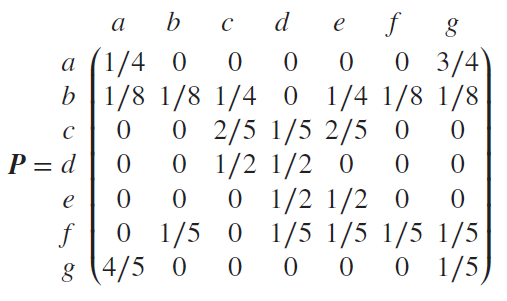

In [2]:
# Matriz de transición
P = sp.Matrix([[1/4,   0,   0,   0,   0,   0, 3/4],
               [1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
               [  0,   0, 2/5, 1/5, 2/5,   0,   0],
               [  0,   0, 1/2, 1/2,   0,   0,   0],
               [  0,   0,   0, 1/2, 1/2,   0,   0],
               [  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
               [4/5,   0,   0,   0,   0,   0, 1/5]])

### 2. Diagrama de transición

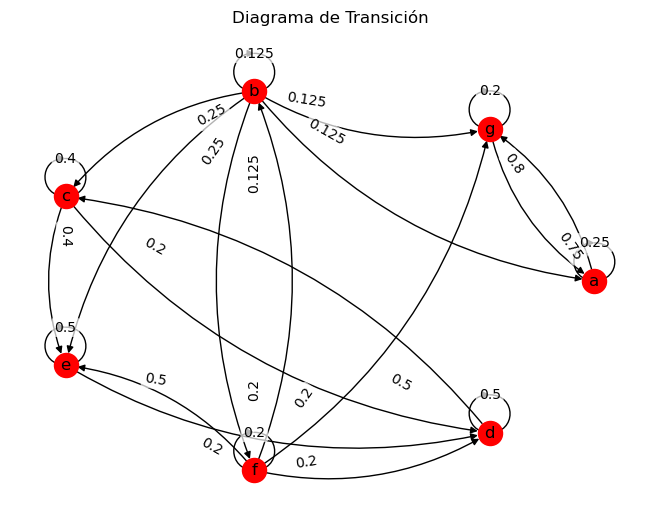

In [ ]:
#Determinamos el tamaño de la matriz (# de estados)
n = P.shape[0]


#Creamos un objeto de grafo dirigido
G = nx.DiGraph()

# Agregar aristas con pesos
for i in range(n):
    for j in range(n):
        if P[i, j] != 0:
            G.add_edge(i, j, weight=float(P[i, j]))

# Nombres de nodos
nodos = ['a', 'b', 'c', 'd', 'e', 'f', 'g']
mapping = {i: nodos[i] for i in range(n)}
G = nx.relabel_nodes(G, mapping)

#Organizamos los nodos en un círculo
pos = nx.circular_layout(G)

pos = {k: v * 1.5 for k, v in pos.items()}  # separa más los nodos

#Dibujamos los nodos y las flechas
nx.draw(G, pos, with_labels=True, connectionstyle='arc3,rad=0.2', node_color='red')

# probabilidad
edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels( G, pos, edge_labels=edge_labels, label_pos=0.2,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.7, ec="none"))

plt.title("Diagrama de Transición")
plt.show()

Se aprecia el diagrama de transición con sus respectivas probabilidades a partir del cual se clasifican los estados, se obtienen las clases y la clasificación de las mismas.

#### 2.1 CLASIFICIACIÓN DE LOS ESTADOS

$$a \leftrightarrow g \qquad b  \leftrightarrow f \qquad c \leftrightarrow d   $$

$$ \qquad \qquad \qquad \quad \qquad c \leftrightarrow e $$

$$ \qquad \qquad \qquad \quad \qquad d \leftrightarrow e $$

Hay 3 clases de comunicación

$$\{a,g\} , \quad \{b,f\}, \quad \{c,d,e\}$$

Donde el periodo de las 3 clases coincide y es $d(i)=1$


#### 2.2 DISTRIBUCIÓN LÍMITE

Primero verifiquemos si es una matriz regular, para ello la elevamos a alguna potencia n

In [3]:
P**2

Matrix([
[  0.6625,        0,       0,    0,       0,        0,   0.3375],
[0.146875, 0.040625, 0.13125,  0.2, 0.28125, 0.040625, 0.159375],
[       0,        0,    0.26, 0.38,    0.36,        0,        0],
[       0,        0,    0.45, 0.35,     0.2,        0,        0],
[       0,        0,    0.25,  0.5,    0.25,        0,        0],
[   0.185,    0.065,    0.15, 0.24,    0.19,    0.065,    0.105],
[    0.36,        0,       0,    0,       0,        0,     0.64]])

In [4]:
P**3

Matrix([
[   0.435625,           0,          0,     0,          0,           0,    0.564375],
[0.169296875, 0.013203125, 0.16265625, 0.275, 0.21140625, 0.013203125, 0.155234375],
[          0,           0,      0.294, 0.422,      0.284,           0,           0],
[          0,           0,      0.355, 0.365,       0.28,           0,           0],
[          0,           0,       0.35, 0.425,      0.225,           0,           0],
[   0.138375,    0.021125,    0.19625, 0.258,    0.18425,    0.021125,    0.180875],
[      0.602,           0,          0,     0,          0,           0,       0.398]])

Al elevar la matriz P notamos que en $P^2$ y $P^3$ hay ceros en las mismas posiciones, por lo que por un teorema se afirma que esas posiciones siempre tendrán ceros, por lo que concluimos que no es una matriz regular y por ende, no tiene una distribución límite.

### 3. DISTRIBUCIÓN CANÓNICA

De acuerdo a las clases, se clasifican como:

$$\{a,g\} \text{ recurrente}$$
$$\{b,f\} \text{ transistorio} $$
$$\{c,d,e\} \text{ recurrente}$$

Y la descomposición canónica de la matriz es:

$$P = \begin{pmatrix}
\frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{8} & \frac{1}{4} & 0 & \frac{1}{4} \\
\frac{1}{5} & \frac{1}{5} & 0 & \frac{1}{5} & 0 & \frac{1}{5} & \frac{1}{5} \\
0 & 0 & \frac{1}{4} & \frac{3}{4} & 0 & 0 & 0 \\
0 & 0 & \frac{4}{5} & \frac{1}{5} & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{2}{5} & \frac{1}{5} & \frac{2}{5} \\
0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{2} & \frac{1}{2} \\
\end{pmatrix} $$

In [5]:
sub1 = sp.Matrix([[1/8, 1/8],
                  [1/5, 1/5]])
sub1

Matrix([
[0.125, 0.125],
[  0.2,   0.2]])

Se tiene la submatriz 1, que corresponde a la clase $\{b,f\}$ que son los estados transistorios

In [6]:
sub2= sp.Matrix([[1/4, 3/4],
                 [4/5, 1/5]])
sub2

Matrix([
[0.25, 0.75],
[ 0.8,  0.2]])

Submatriz 2 que corresponde a la clase $\{a,g\}$ que son estados recurrentes

In [7]:
sub3 = sp.Matrix([[2/5, 1/5, 2/5],
                  [1/2, 1/2,   0],
                  [0,   1/2, 1/2]])
sub3

Matrix([
[0.4, 0.2, 0.4],
[0.5, 0.5,   0],
[  0, 0.5, 0.5]])

Submatriz 3 que corresponde a la clase $\{c,d,e\}$ de igual manera es un estado recurrente

In [8]:
Pcan = sp.Matrix([[1/8, 1/8, 1/8, 1/8, 1/4, 0,   1/4],
                  [1/5, 1/5, 0,   1/5, 0,   1/5, 1/5],
                  [0,   0,   1/4, 3/4, 0,   0,   0],
                  [0,   0,   4/5, 1/5, 0,   0,   0],
                  [0,   0,   0,   0,   2/5, 1/5, 2/5],
                  [0,   0,   0,   0,   1/2, 1/2, 0],
                  [0,   0,   0,   0,   0,   1/2, 1/2]])

Pcan

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

Y la descomposición canónica es la matriz que se aprecia, donde los estados ahora están en el orden $b,f,a,g,c,d,e$ tanto filas como columnas, pero las probabilidades no cambián, solo se "reorganizaron".

In [9]:
Pcan**10

Matrix([
[5.05661934518814e-6, 5.05661934518814e-6, 0.171988654922659, 0.161341307331112, 0.222173673923513, 0.266708044001801, 0.177778206582227],
[8.09059095230103e-6, 8.09059095230103e-6,   0.1724017220618, 0.160926217544232,  0.22220883367762, 0.266664125602881, 0.177782919931563],
[                  0,                   0, 0.517354654010254, 0.482645345989746,                 0,                 0,                 0],
[                  0,                   0, 0.514821702389063, 0.485178297610938,                 0,                 0,                 0],
[                  0,                   0,                 0,                 0,      0.3333117166,      0.4000406558,      0.2666476276],
[                  0,                   0,                 0,                 0,      0.3333095345,      0.3999736235,       0.266716842],
[                  0,                   0,                 0,                 0,      0.3333960525,       0.399988745,      0.2666152025]])

La matriz canónica elevada a una potencia $n$

Nótemos que al elevar cada bloque al mismo exponente $n$ coincide con la descomposición en el bloque correspondiente

In [10]:
sub1**10

Matrix([
[5.05661934518814e-6, 5.05661934518814e-6],
[8.09059095230103e-6, 8.09059095230103e-6]])

Submatriz 1 elevada a una potencia 10 donde coincide con su bloque de la matriz canónica elevada a la misma potencia.

In [11]:
sub2**10

Matrix([
[0.517354654010254, 0.482645345989746],
[0.514821702389063, 0.485178297610938]])

Submatriz 2 elevada a una potencia 10 donde coincide con su bloque de la matriz canónica elevada a la misma potencia.

In [12]:
sub3**10

Matrix([
[0.3333117166, 0.4000406558, 0.2666476276],
[0.3333095345, 0.3999736235,  0.266716842],
[0.3333960525,  0.399988745, 0.2666152025]])

Submatriz 3 elevada a una potencia 10 donde coincide con su bloque de la matriz canónica elevada a la misma potencia.

Esto quiere decir que el límite de la potencia n-esima es igual a las distribuciones límite de las submatrices.

### 4. DESCOMPOSICIÓN CANÓNICA DE CUALQUIER MATRIZ

In [13]:
def canonica(P):
    #Guarda el número de estados de la cadena (desde 0)
    n = P.shape[0]

    def R(i):
        #Guardar los estados alcanzables

        #Expolorando caminos
        s = {i}
        stack = [i]
        while stack:
            #Mientras haya estados por revisar, toma uno de la fila y lo llama u.
            u = stack.pop()
            for v in range(n):
                if P[u,v] != 0 and v not in s: #estados de v con Pvv distintos de 0
                    s.add(v)
                    stack.append(v)
        return s

    #Estados que todavía no han sido clasificados.
    no = set(range(n))

    #Guardar las clases comunicantes
    clases = []

    #Mientras haya estados sin clasificar, toma uno de ellos.
    while no:
        i = next(iter(no))

        #Calcula los estados alcanzables desde i.
        Ri = R(i)

        #Formar la clase comunicante de i.
        c = {j for j in Ri if i in R(j)}

        #Guarda la clase encontrada y elimina esos estados del conjunto no.
        clases.append(c)
        no -= c

    #Al principio supone que todos los estados son transitorios.
    T = set(range(n))

    #Revisar si la clase es cerrada
    for c in clases:
        if all(P[i,j]==0 or j in c for i in c for j in range(n)):
            T -= c

    #Convierte el conjunto de estados transitorios en lista.
    T = list(T)

    #Forma la lista de estados recurrentes.
    Rr = [i for c in clases for i in c if i not in T]

    #Primero poner los transitorios y luego los recurrentes.
    orden = T + Rr

    #Regresar la matriz en su forma canónica
    return P.extract(orden, orden)

Esto produce la forma canónica:

$$P =
\begin{pmatrix}
Q & R \\
0 & S
\end{pmatrix}$$

donde:

* Q representa transiciones entre estados transitorios.
* R representa transiciones de transitorios a recurrentes.
* 0 representa que de recurrentes no se regresa a transitorios.
* S representa transiciones dentro de clases recurrentes.

La siguiente función realiza en automatica la descomposición canónica de una matriz $P$.

In [14]:
canonica(P)

Matrix([
[0.125, 0.125, 0.125, 0.125, 0.25,   0, 0.25],
[  0.2,   0.2,     0,   0.2,    0, 0.2,  0.2],
[    0,     0,  0.25,  0.75,    0,   0,    0],
[    0,     0,   0.8,   0.2,    0,   0,    0],
[    0,     0,     0,     0,  0.4, 0.2,  0.4],
[    0,     0,     0,     0,  0.5, 0.5,    0],
[    0,     0,     0,     0,    0, 0.5,  0.5]])

Se llama la función y como prueba se aplica la matriz que $P$ que se ha venido trabajando y se obtuvo analíticamente, la cual coincide con la dada por la función.